Matrix Size  | Naive Time (s)  | Numpy Time (s)
--------------------------------------------------
   3x3       | 0.002884        | 0.000028       
   6x6       | 0.000048        | 0.000013       
  12x12      | 0.000310        | 0.000013       
  24x24      | 0.002232        | 0.000023       
  48x48      | 0.018646        | 0.000184       
  96x96      | 0.146634        | 0.000678       
 192x192     | 1.151258        | 0.007890       
 384x384     | 10.125656       | 0.115906       


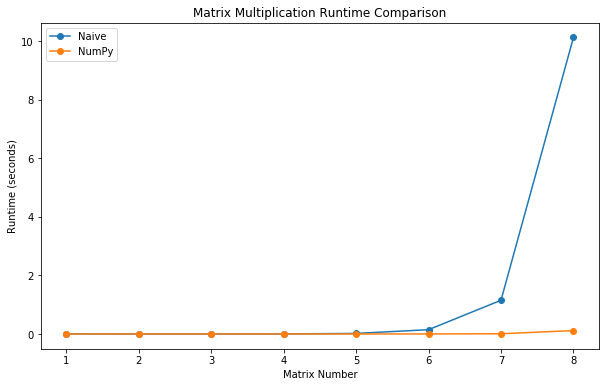

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import time

def naive_matrix_multiplication(A, B):
    n = len(A)
    C = [[0] * n for _ in range(n)]

    for i in range(n):
        for j in range(n):
            for k in range(n):
                C[i][j] += A[i][k] * B[k][j]

    return C

# Build 8 matrix sizes: 3x3, 6x6, 12x12, ...
sizes = [3]
for i in range(7):
    sizes.append(sizes[-1] * 2)

naiveTimes = []
numpyTimes = []
matrixNumbers = list(range(1, 9))

# Generate matrix pairs and time both methods
for size in sizes:
    A_np = np.random.randint(0, 10, (size, size))
    B_np = np.random.randint(0, 10, (size, size))

    # Convert to Python lists for naive multiplication
    A_list = A_np.tolist()
    B_list = B_np.tolist()

    # Time naive multiplication
    start = time.time()
    naive_result = naive_matrix_multiplication(A_list, B_list)
    end = time.time()
    naiveTimes.append(end - start)

    # Time NumPy multiplication
    start = time.time()
    numpy_result = np.dot(A_np, B_np)
    end = time.time()
    numpyTimes.append(end - start)

# Print runtimes
print("Matrix Size  | Naive Time (s)  | Numpy Time (s)")
print("-" * 50)


for i in range(len(sizes)):
    print(f"{sizes[i]:>4}x{sizes[i]:<7} | {naiveTimes[i]:<15.6f} | {numpyTimes[i]:<15.6f}")

# Plot runtimes
plt.figure(figsize=(10, 6))
plt.plot(matrixNumbers, naiveTimes, marker='o', label='Naive')
plt.plot(matrixNumbers, numpyTimes, marker='o', label='NumPy')
plt.title('Matrix Multiplication Runtime Comparison')
plt.xlabel('Matrix Number')
plt.ylabel('Runtime (seconds)')
plt.xticks(matrixNumbers)
plt.legend()
plt.show()
# The times for the numpy are faster than the custom naive method for every matrix size. The bigger the matrix the bigger the gap between times.  